# Orbital Debris Visualizations

This notebook is visualization-only and reads from the SQLite database.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import utility as utils
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Initialize Visualization Settings

# Set the Palette (High Contrast Neon)
sns.set_palette("plasma") 

# Set the Background (Deep Space Black)
plt.style.use('dark_background')

plt.rcParams.update({
    "grid.alpha": 0.2,            # Faint, non-intrusive grid
    "axes.facecolor": "black",    # No grey haze in plot area
    "figure.facecolor": "black",  # No grey haze in outer area
    "text.color": "white",        # High contrast text
    "axes.labelcolor": "white",   # Axis labels
    "xtick.color": "white",       # Ticks
    "ytick.color": "white",
    "legend.facecolor": "black",  # Legend background
    "legend.edgecolor": "white"   # Legend border
})

In [2]:
# Load ALL query results from notebook 05.
pq1 = utils.load_query_result('pq1_orbit_trends').sort_values('launch_year').reset_index(drop=True).copy()
pq2 = utils.load_query_result('pq2_high_risk').sort_values('altitude_band').reset_index(drop=True).copy()

### Primary Question 1: Growth and Decoupling Baseline

This analysis treats decoupling year as a model-selected result, not a pre-asserted fact. The split year is selected by testing candidate years and choosing the one with the lowest RMSE from a two-regime fit (linear pre-split, exponential post-split), subject to minimum sample counts on both sides of the split. Current partial year data is excluded from fitting to avoid bias.   

In [3]:
# Exclude the current partial year from fitting.
current_year = pd.Timestamp.now().year
pq1_fit = pq1[pq1['launch_year'] < current_year].copy()

# set up the 3 year rolling average for visual smoothing (but not used in curve fitting).
pq1['objects_3yr_avg'] = pq1['objects_in_orbit'].rolling(3, min_periods=1).mean()
pq1_fit['objects_3yr_avg'] = pq1_fit['objects_in_orbit'].rolling(3, min_periods=1).mean()

# split selection (no hard coded split year).
split_year, split_diagnostics = utils.choose_split_year(
    pq1_fit,
    y_col='objects_in_orbit'
)

# Fit growth regimes for yearly data, using the selected split year.
pre, post, m_pre, b_exp, doubling_time_years = utils.fit_growth_regimes(
    pq1_fit,
    split_year=split_year,
    y_col='objects_in_orbit'
 )

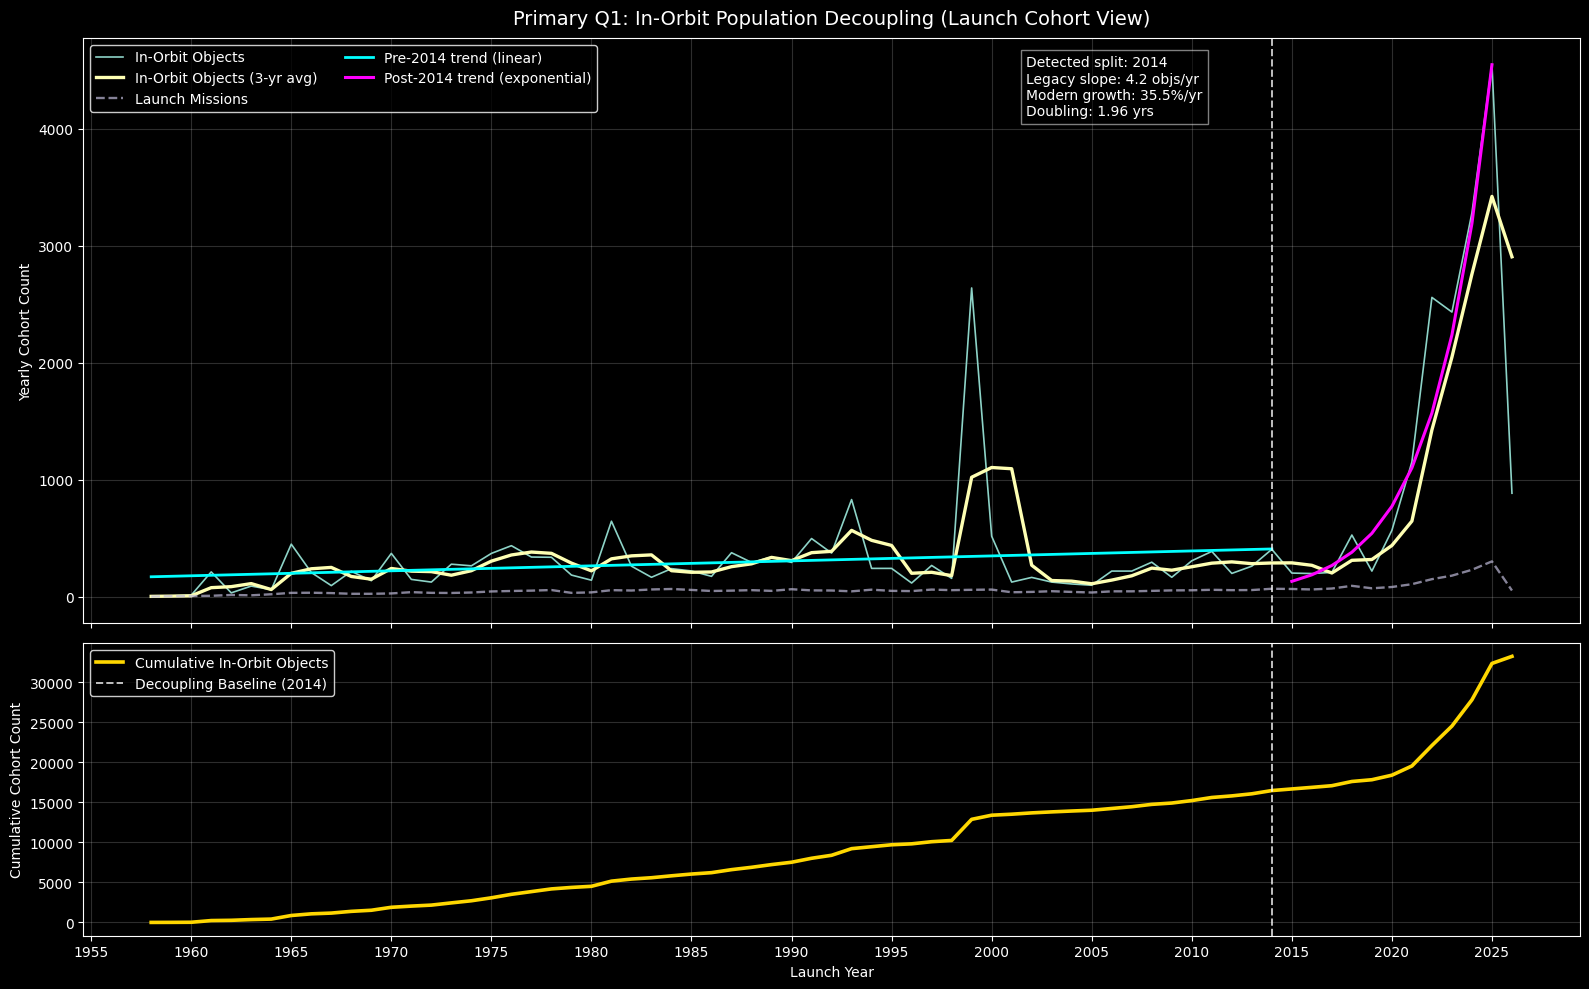

,split_year,pre_n,post_n,rmse,total_sse
0,2014,57,11,340.319713,7.875590e+06
1,2015,58,10,343.666175,8.031238e+06
2,2019,62,6,347.506509,8.211733e+06
3,2016,59,9,351.123200,8.383550e+06
4,2017,60,8,351.691760,8.410722e+06
5,2013,56,12,364.695029,9.044168e+06
6,2012,55,13,388.506971,1.026376e+07
7,2018,61,7,395.237327,1.062245e+07
8,2011,54,14,406.519813,1.123757e+07
9,2010,53,15,448.592541,1.368400e+07


In [4]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
 )

# Top graph lineplots.
sns.lineplot(
    data=pq1,
    x='launch_year',
    y='objects_in_orbit',
    linewidth=1.2,
    ax=ax1,
    label='In-Orbit Objects'
 )

sns.lineplot(
    data=pq1,
    x='launch_year',
    y='objects_3yr_avg',
    linewidth=2.4,
    ax=ax1,
    label='In-Orbit Objects (3-yr avg)'
 )

sns.lineplot(
    data=pq1,
    x='launch_year',
    y='launch_missions',
    linewidth=1.7,
    linestyle='--',
    alpha=0.7,
    ax=ax1,
    label='Launch Missions'
 )

sns.lineplot(
    data=pre,
    x='launch_year',
    y='trend_linear',
    ax=ax1,
    color='cyan',
    linewidth=2.0,
    label=f'Pre-{split_year} trend (linear)'
 )

sns.lineplot(
    data=post,
    x='launch_year',
    y='trend_exponential',
    ax=ax1,
    color='magenta',
    linewidth=2.2,
    label=f'Post-{split_year} trend (exponential)'
 )

ax1.axvline(split_year, color='white', linestyle='--', alpha=0.75, linewidth=1.4)

ax1.text(
    0.63, 0.97,
    f'Detected split: {split_year}\n'
    f'Legacy slope: {m_pre:,.1f} objs/yr\n'
    f'Modern growth: {b_exp:.1%}/yr\n'
    f'Doubling: {doubling_time_years:.2f} yrs',
    transform=ax1.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(facecolor='black', edgecolor='white', alpha=0.5)
 )

ax1.set_title('Primary Q1: In-Orbit Population Decoupling (Launch Cohort View)', fontsize=14, pad=10)
ax1.set_ylabel('Yearly Cohort Count')
ax1.grid(alpha=0.18)
ax1.legend(loc='upper left', ncol=2, frameon=True)

# Bottom graph lineplot (cumulative cohort stock).
sns.lineplot(
    data=pq1,
    x='launch_year',
    y='cumulative_in_orbit',
    color='gold',
    linewidth=2.6,
    ax=ax2,
    label='Cumulative In-Orbit Objects'
 )

ax2.axvline(
    split_year,
    color='white',
    linestyle='--',
    alpha=0.75,
    linewidth=1.4,
    label=f'Decoupling Baseline ({split_year})'
 )

ax2.set_xlabel('Launch Year')
ax2.set_ylabel('Cumulative Cohort Count')
ax2.grid(alpha=0.18)
ax2.legend(loc='upper left', frameon=True)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('../images/launch_trends_pq1.svg', bbox_inches='tight')
plt.savefig('../images/launch_trends_pq1.png', bbox_inches='tight', dpi=300)
plt.show()

display(split_diagnostics.head(10))

### Primary Question 2: High-Risk Object Distribution by Orbit Class and Altitude Band
How are high-risk objects (by velocity and kinetic energy) distributed across orbit classes and altitude bands, especially in the 400 - 600 km LEO?

The high-risk population is overwhelmingly dominated by payloads and rocket bodies, with debris contributing very little to the high-risk count. This suggests that the most dangerous objects in orbit are intact spacecraft and spent rocket stages, rather than fragments of debris. The danger from debris comes mainly from the large number of small, high-velocity fragments that can cause significant damage despite their small size.

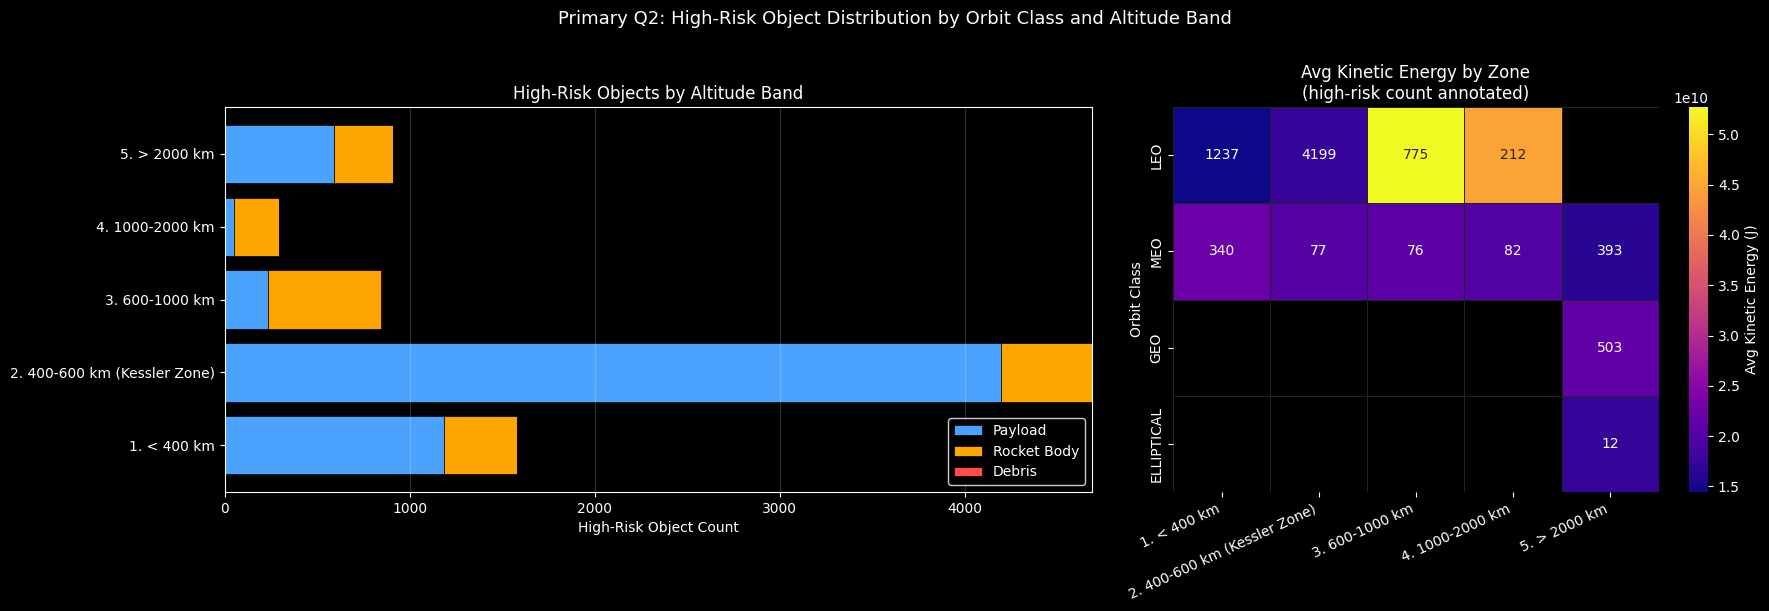

In [5]:
# these will match the sql case from the banded cte in our query
altitude_order = [
    "1. < 400 km",
    "2. 400-600 km (Kessler Zone)",
    "3. 600-1000 km",
    "4. 1000-2000 km",
    "5. > 2000 km"
 ]

orbit_order = ['LEO', 'MEO', 'GEO', 'ELLIPTICAL']

# Dictionary: Key(str), Value(tuple(str, str))
# (segment name) : tuple(column in pq2, color for plot)
segments = {
    'Payload':     ('payload_high_risk', '#4CA3FF'),
    'Rocket Body': ('rb_high_risk',      '#FFA500'),
    'Debris':      ('debris_high_risk',  '#FF4C4C'),
}

# Create subset of pq2 that includes only the altitude bands found in our query, ignoring unknown or out
# of range data. This minimizes noise in the bar chart and heatmap from irrelevant altitude bands.
pq2_bar = pq2[pq2['altitude_band'].isin(altitude_order)].copy()

# use pd.Categorical to set the altitude_band order for plotting, then group by altitude_band and sum 
# the high risk counts for each segment type to get totals for the bar chart.
pq2_bar['altitude_band'] = pd.Categorical(pq2_bar['altitude_band'], categories=altitude_order, ordered=True)
pq2_bar = pq2_bar.groupby('altitude_band', observed=True)[['debris_high_risk', 'payload_high_risk', 'rb_high_risk']
    ].sum().reset_index()

# use pivot_table to create a matrix of avg kinetic energy values for the heatmap
# matrix structure: rows = orbit_class, cols = altitude_band, cell value = avg_kinetic_joules
# this works by setting the index to the orbit class and the columns to the altitude band,
# then filling the cells with the mean avg_kinetic_joules for each orbit class / altitude band combination.
heat_data = pq2.pivot_table(index='orbit_class', columns='altitude_band', values='avg_kinetic_joules', aggfunc='mean')
heat_data = heat_data.reindex(index=orbit_order, columns=altitude_order)

# use pivot_table to create a matrix of high risk object counts for the heatmap.
# matrix structure: rows = orbit_class, cols = altitude_band, cell value = high_risk_count
# this works by setting the index to the orbit class and the columns to the altitude band,
# then filling the cells with the sum of high_risk_count for each orbit class / altitude band combination.
heat_counts = pq2.pivot_table(index='orbit_class', columns='altitude_band', values='high_risk_count', aggfunc='sum')
heat_counts = heat_counts.reindex(index=orbit_order, columns=altitude_order)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1.4]})

# Stacked horizontal bar on the left
left = np.zeros(len(pq2_bar))
for label, (col, color) in segments.items():
    ax1.barh(pq2_bar['altitude_band'], pq2_bar[col], left=left, color=color, label=label, edgecolor='black', linewidth=0.5)
    left += pq2_bar[col].values

ax1.set_title('High-Risk Objects by Altitude Band')
ax1.set_xlabel('High-Risk Object Count')
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.18)

# Heatmap on the right
sns.heatmap(
    heat_data,
    ax=ax2,
    cmap='plasma',
    annot=heat_counts.fillna(0).astype(int),
    fmt='d',
    linewidths=0.5,
    linecolor='#222222',
    cbar_kws={'label': 'Avg Kinetic Energy (J)'}
)

ax2.set_title('Avg Kinetic Energy by Zone\n(high-risk count annotated)')
ax2.set_xlabel('')
ax2.set_ylabel('Orbit Class')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha='right')

plt.suptitle('Primary Q2: High-Risk Object Distribution by Orbit Class and Altitude Band', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../images/high_risk_distribution_pq2.svg', bbox_inches='tight')
plt.savefig('../images/high_risk_distribution_pq2.png', bbox_inches='tight', dpi=300)
plt.show()